# Final Project - Chem 277B
### **Structure-Aware Resistance Prediction in Mycobacterium tuberculosis via MIC Regression**

### Contributors:
Cris Zong, Ethan Chan, Isabella Beatrice Bonomi, Robert Craig Wallace, Sidney Alexa Brooks

### 1) Objective and Goal of the Project

Objective: To develop a machine learning model that predicts M. tuberculosis drug resistance by jointly encoding mutation profiles and drug molecular structure, rather than treating each drug as an independent categorical label.

Goal: To accurately predict resistance confidence levels from mutation loci and Morgan fingerprints, and ultimately generalize to novel anti-TB compounds not present in existing catalogues.

**Note:** prior to going through this walkthrough, instructions for downloading data will be included in the README markdown file.

In [ ]:
# Import standard libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
# import pubchempy as pcp

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from rdkit import Chem
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator
from rdkit.DataStructs import ConvertToNumpyArray


In [3]:
# Load training data
master_file = pd.read_csv("WHO-UCN-TB-2023.6-eng_catalogue_master_file.txt", sep="\t")

# Let's take a look at the data
master_file.head(100)

/var/folders/_h/ppym6hs50lx51lmb80t8l84m0000gq/T/ipykernel_59535/2925814549.py:2: DtypeWarning: Columns (36,37,99,100,102,103,106,108,112) have mixed types. Specify dtype option on import or set low_memory=False.
  master_file = pd.read_csv("WHO-UCN-TB-2023.6-eng_catalogue_master_file.txt", sep="\t")


,drug,gene,mutation,variant,tier,effect,genomic position,algorithm_pass_DATASET ALL,Present_SOLO_SR_DATASET ALL,Present_SOLO_R_DATASET ALL,...,Additional grading criteria applied,FINAL CONFIDENCE GRADING,Comment,CHANGES vs ver1,"Relaxed thresholds simulation (BDQ_Rv0678, CFZ_Rv0678, INH_katG, DLM_ddn/fbiA/fbiB/fbiC/fgd1/Rv2983)",Silent mutation,Listed in abridged tables,Additional grading,Footnote,CHANGES vs ver1.1
0,Amikacin,bacA,c.102G>A,bacA_c.102G>A,2,synonymous_variant,"(see ""Genomic_coordinates"" sheet)",NaN,NaN,NaN,...,Silent mutation,4) Not assoc w R - Interim,NaN,Now listed,NaN,Silent mutation,no,NaN,NaN,0
1,Amikacin,bacA,c.1044G>A,bacA_c.1044G>A,2,synonymous_variant,"(see ""Genomic_coordinates"" sheet)",NaN,NaN,NaN,...,NaN,5) Not assoc w R,NaN,Now listed,NaN,Silent mutation,no,NaN,NaN,0
2,Amikacin,bacA,c.105C>G,bacA_c.105C>G,2,synonymous_variant,"(see ""Genomic_coordinates"" sheet)",NaN,NaN,NaN,...,Silent mutation,4) Not assoc w R - Interim,NaN,Now listed,NaN,Silent mutation,no,NaN,NaN,0
3,Amikacin,bacA,c.1065T>G,bacA_c.1065T>G,2,synonymous_variant,"(see ""Genomic_coordinates"" sheet)",NaN,NaN,NaN,...,Silent mutation,4) Not assoc w R - Interim,NaN,Now listed,NaN,Silent mutation,no,NaN,NaN,0
4,Amikacin,bacA,c.1080G>A,bacA_c.1080G>A,2,synonymous_variant,"(see ""Genomic_coordinates"" sheet)",NaN,NaN,NaN,...,Silent mutation,4) Not assoc w R - Interim,NaN,Now listed,NaN,Silent mutation,no,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,Amikacin,bacA,c.783C>T,bacA_c.783C>T,2,synonymous_variant,"(see ""Genomic_coordinates"" sheet)",NaN,NaN,NaN,...,Silent mutation,4) Not assoc w R - Interim,NaN,Now listed,NaN,Silent mutation,no,NaN,NaN,0
96,Amikacin,bacA,c.-81_-76dupTCGGTG,bacA_c.-81_-76dupTCGGTG,2,upstream_gene_variant,2064803,1.0,1.0,0.0,...,NaN,3) Uncertain significance,NaN,New Uncertain,NaN,NaN,no,NaN,NaN,0
97,Amikacin,bacA,c.84G>C,bacA_c.84G>C,2,synonymous_variant,"(see ""Genomic_coordinates"" sheet)",NaN,NaN,NaN,...,Silent mutation,4) Not assoc w R - Interim,NaN,Now listed,NaN,Silent mutation,no,NaN,NaN,0
98,Amikacin,bacA,deletion,bacA_deletion,2,feature_ablation,"(see ""Genomic_coordinates"" sheet)",NaN,0.0,0.0,...,NaN,3) Uncertain significance,NaN,New Uncertain,NaN,NaN,no,NaN,NaN,0


### 2) Data Cleaning and Ordinal Encoding

In [ ]:
# non_metadata_columns = ['Present_SOLO_SR_DATASET ALL', 'Present_SOLO_SR_DATASET WHO', 'Present_SOLO_R_DATASET ALL', 'Present_SOLO_R_DATASET WHO', 'Present_SOLO_S_DATASET ALL', 'Present_SOLO_S_DATASET WHO', 'Present_R_DATASET ALL', 'Present_R_DATASET WHO', 'Present_S_DATASET ALL', 'Present_S_DATASET WHO', 'Absent_R_DATASET ALL', 'Absent_R_DATASET WHO', 'Absent_S_DATASET ALL', 'Absent_S_DATASET WHO', 'Sens_DATASET ALL', 'Sens_DATASET WHO', 'Sens_lb_DATASET ALL', 'Sens_lb_DATASET WHO', 'Sens_ub_DATASET ALL', 'Sens_ub_DATASET WHO', 'Spec_DATASET ALL', 'Spec_DATASET WHO', 'Spec_lb_DATASET ALL', 'Spec_lb_DATASET WHO', 'Spec_ub_DATASET ALL', 'Spec_ub_DATASET WHO', 'PPV_DATASET ALL', 'PPV_DATASET WHO', 'PPV_lb_DATASET ALL', 'PPV_lb_DATASET WHO', 'PPV_ub_DATASET ALL', 'PPV_ub_DATASET WHO', 'PPV_SOLO_DATASET ALL', 'PPV_SOLO_DATASET WHO', 'PPV_SOLO_lb_DATASET ALL', 'PPV_SOLO_lb_DATASET WHO', 'PPV_SOLO_ub_DATASET ALL', 'PPV_SOLO_ub_DATASET WHO', 'PPV_conditional_SOLO_DATASET ALL', 'PPV_conditional_SOLO_DATASET WHO', 'OR_SOLO_DATASET ALL', 'OR_SOLO_DATASET WHO', 'OR_SOLO_exact_lb_DATASET ALL', 'OR_SOLO_exact_lb_DATASET WHO', 'OR_SOLO_exact_ub_DATASET ALL', 'OR_SOLO_exact_ub_DATASET WHO', 'OR_SOLO_pvalue_DATASET ALL', 'OR_SOLO_pvalue_DATASET WHO', 'OR_SOLO_FE_sig_DATASET ALL', 'OR_SOLO_FE_sig_DATASET WHO', 'Neutral_masked_DATASET ALL', 'Neutral_masked_DATASET WHO', 'OR_DATASET ALL', 'OR_DATASET WHO', 'OR_exact_lb_DATASET ALL', 'OR_exact_lb_DATASET WHO', 'OR_exact_ub_DATASET ALL', 'OR_exact_ub_DATASET WHO', 'Sens_SOLO_DATASET ALL', 'Sens_SOLO_DATASET WHO', 'Sens_SOLO_lb_DATASET ALL', 'Sens_SOLO_lb_DATASET WHO', 'Sens_SOLO_ub_DATASET ALL', 'Sens_SOLO_ub_DATASET WHO', 'Spec_SOLO_DATASET ALL', 'Spec_SOLO_DATASET WHO', 'Spec_SOLO_lb_DATASET ALL', 'Spec_SOLO_lb_DATASET WHO', 'Spec_SOLO_ub_DATASET ALL', 'Spec_SOLO_ub_DATASET WHO']
# these columns already have some of the results that PPV_SOLO uses. They are computed on the same result data, and would be basically giving the model the answer
derived_cheating_columns = 



# Sens, Spec, OR, k and all their variants — all calculated from the same Present_R/S and Absent_R/S counts
# Present_R, Present_S, Absent_R, Absent_S — these ARE the raw data PPV_SOLO is calculated from
# Present_SOLO_R, Present_SOLO_S, Present_SOLO_SR — same issue, PPV_SOLO = Present_SOLO_R / Present_SOLO_SR
# FINAL CONFIDENCE GRADING — derived from all of the above
# OR_SOLO_FE_sig, Neutral_masked — downstream of the same data

# master_file = master_file[non_metadata_columns]

master_file_clean = master_file.dropna(subset=["FINAL CONFIDENCE GRADING"])

master_file_clean["gene"] = master_file_clean["gene"].str.strip()
master_file_clean["mutation"] = master_file_clean["mutation"].str.strip()
master_file_clean["FINAL CONFIDENCE GRADING"] = master_file_clean["FINAL CONFIDENCE GRADING"].str.strip()

print(master_file_clean["FINAL CONFIDENCE GRADING"].unique())

# ordinally encode resistance grades
grading_scheme = {
    "5) Not assoc w R": 0,
    "4) Not assoc w R - Interim'": 1,
    "3) Uncertain significance": 2,
    "2) Assoc w R - Interim": 3,
    "1) Assoc w R": 4
}

master_file_clean["grade_ordinal"] = master_file_clean["FINAL CONFIDENCE GRADING"].map(grading_scheme)
master_file_clean = master_file_clean.dropna(subset=["grade_ordinal"])

# remove duplicates
master_file_clean = master_file_clean.drop_duplicates(subset=["mutation", "drug"])
#print(master_file_clean)

# keep only necessary columns
model_df = master_file_clean[[
    "gene",
    "mutation",
    "drug",
    "grade_ordinal"
]].copy()

# for c in master_file_clean.columns:
#     print(f"{c}: {master_file_clean.iloc[1][c]}")
mutations = sorted(list(model_df['mutation'].unique()))
print(len(mutations))
for m in mutations[:300]:
    print(m)

# print(model_df.head())
# print(len(model_df))



['4) Not assoc w R - Interim' '5) Not assoc w R'
 '3) Uncertain significance' '2) Assoc w R - Interim' '1) Assoc w R']
19553
LoF
c.-1001G>A
c.-1002C>T
c.-1004G>A
c.-100A>G
c.-100C>A
c.-100C>G
c.-100C>T
c.-100G>A
c.-100T>C
c.-1016C>T
c.-1017G>A
c.-1018C>G
c.-1019C>T
c.-101A>T
c.-101C>G
c.-101G>A
c.-101T>C
c.-101_-51delTGACCTCCGCCGGCGACGATGCAGAGCGCAGCGATGAGGAGGAGCGGCGCT
c.-1021A>G
c.-1022G>A
c.-1023A>C
c.-1025G>A
c.-1028G>A
c.-102A>G
c.-102C>T
c.-102G>A
c.-102G>C
c.-102_-78delGCAACCTTTTGGTCACTCAATCACA
c.-102_-97delTCGGGGinsC
c.-1035C>T
c.-1036T>C
c.-103C>G
c.-103C>T
c.-103G>C
c.-1043T>C
c.-104A>C
c.-104A>G
c.-104C>A
c.-104C>T
c.-104T>C
c.-104_-103insC
c.-104delC
c.-1053G>A
c.-1053G>T
c.-1054C>T
c.-1058G>A
c.-1058G>T
c.-105A>G
c.-105C>G
c.-105C>T
c.-105G>A
c.-105T>C
c.-1061G>T
c.-106A>G
c.-106C>T
c.-106G>A
c.-106G>C
c.-1072C>T
c.-1077G>A
c.-107A>C
c.-107C>G
c.-107G>A
c.-107_-106insT
c.-1085G>A
c.-1086G>A
c.-108A>G
c.-108A>T
c.-108C>T
c.-108G>A
c.-108G>T
c.-1092G>A
c.-1093C>T
c.-1094G>A
c.

In [38]:
# Splitting the mutation column up to make fewer columns when one hot encoding
import re
# Amino acid 3-letter to 1-letter code map
AA_MAP = {
    'Ala': 'A', 'Arg': 'R', 'Asn': 'N', 'Asp': 'D', 'Cys': 'C',
    'Gln': 'Q', 'Glu': 'E', 'Gly': 'G', 'His': 'H', 'Ile': 'I',
    'Leu': 'L', 'Lys': 'K', 'Met': 'M', 'Phe': 'F', 'Pro': 'P',
    'Ser': 'S', 'Thr': 'T', 'Trp': 'W', 'Tyr': 'Y', 'Val': 'V',
    'Ter': '*', 'Stop': '*'
}

def parse_aa(code):
    """Convert 3-letter amino acid code to 1-letter, or return as-is if already 1-letter or stop."""
    if code == '*':
        return '*'
    return AA_MAP.get(code, code)


def extract_features(mutation):

    PREFIX = r'[cn]\.'

    # -------------------------
    # PROTEIN-LEVEL: p. notation
    # -------------------------

    # Stop extension: p.Ter559Glnext*? or p.Ter559ext*? or p.Ter628Serext*?
    p_ext = re.match(r'p\.Ter(\d+)([A-Z][a-z]{2})?ext\*\?$', mutation)
    if p_ext:
        pos, alt_aa = p_ext.groups()
        return {'mut_type': 'extension', 'position': int(pos), 'del_len': 0, 'ins_len': 0,
                'ref': '*', 'alt': parse_aa(alt_aa) if alt_aa else None}

    # Stop codon unknown delins: p.Ter839delins???
    p_ter_delins = re.match(r'p\.Ter(\d+)delins\?+$', mutation)
    if p_ter_delins:
        pos = p_ter_delins.group(1)
        return {'mut_type': 'delins', 'position': int(pos), 'del_len': 1, 'ins_len': 0,
                'ref': '*', 'alt': None}

    # Frameshift: p.Asp379fs
    p_fs = re.match(r'p\.([A-Z][a-z]{2})(\d+)fs$', mutation)
    if p_fs:
        ref_aa, pos = p_fs.groups()
        return {'mut_type': 'frameshift', 'position': int(pos), 'del_len': 0, 'ins_len': 0,
                'ref': parse_aa(ref_aa), 'alt': None}

    # Stop/nonsense: p.Trp122*
    p_stop = re.match(r'p\.([A-Z][a-z]{2})(\d+)\*$', mutation)
    if p_stop:
        ref_aa, pos = p_stop.groups()
        return {'mut_type': 'nonsense', 'position': int(pos), 'del_len': 0, 'ins_len': 0,
                'ref': parse_aa(ref_aa), 'alt': '*'}

    # Malformed nonsense: p.TrpLeu266*
    p_malformed_stop = re.match(r'p\.([A-Z][a-z]{2}[A-Z][a-z]{2})(\d+)\*$', mutation)
    if p_malformed_stop:
        ref_aa, pos = p_malformed_stop.groups()
        return {'mut_type': 'nonsense', 'position': int(pos), 'del_len': 0, 'ins_len': 0,
                'ref': None, 'alt': '*'}

    # Uncertain: p.Met1?
    p_uncertain = re.match(r'p\.([A-Z][a-z]{2})(\d+)\?$', mutation)
    if p_uncertain:
        ref_aa, pos = p_uncertain.groups()
        return {'mut_type': 'uncertain', 'position': int(pos), 'del_len': 0, 'ins_len': 0,
                'ref': parse_aa(ref_aa), 'alt': None}

    # Single AA deletion: p.Leu95del
    p_single_del = re.match(r'p\.([A-Z][a-z]{2})(\d+)del$', mutation)
    if p_single_del:
        ref_aa, pos = p_single_del.groups()
        return {'mut_type': 'del', 'position': int(pos), 'del_len': 1, 'ins_len': 0,
                'ref': parse_aa(ref_aa), 'alt': None}

    # Range AA deletion: p.Val3_Thr4del
    p_range_del = re.match(r'p\.([A-Z][a-z]{2})(\d+)_([A-Z][a-z]{2})(\d+)del$', mutation)
    if p_range_del:
        ref_aa, start, _, end = p_range_del.groups()
        return {'mut_type': 'del', 'position': int(start), 'del_len': abs(int(end) - int(start)) + 1,
                'ins_len': 0, 'ref': parse_aa(ref_aa), 'alt': None}

    # Range AA duplication: p.His68_Leu70dup
    p_range_dup = re.match(r'p\.([A-Z][a-z]{2})(\d+)_([A-Z][a-z]{2})(\d+)dup$', mutation)
    if p_range_dup:
        ref_aa, start, _, end = p_range_dup.groups()
        return {'mut_type': 'dup', 'position': int(start), 'del_len': 0,
                'ins_len': abs(int(end) - int(start)) + 1, 'ref': parse_aa(ref_aa), 'alt': None}

    # Range AA insertion: p.Val389_Asp390insGly  (one or more 3-letter AA codes)
    p_range_ins = re.match(r'p\.([A-Z][a-z]{2})(\d+)_([A-Z][a-z]{2})(\d+)ins((?:[A-Z][a-z]{2})+)$', mutation)
    if p_range_ins:
        ref_aa, start, _, end, ins_aas = p_range_ins.groups()
        ins_count = len(re.findall(r'[A-Z][a-z]{2}', ins_aas))
        return {'mut_type': 'ins', 'position': int(start), 'del_len': 0,
                'ins_len': ins_count, 'ref': parse_aa(ref_aa), 'alt': None}

    # Range AA delins: p.Pro14_Val301delinsLeu or p.Leu443_Lys446delinsProGln
    p_range_delins = re.match(r'p\.([A-Z][a-z]{2})(\d+)_([A-Z][a-z]{2})(\d+)delins((?:[A-Z][a-z]{2})+)$', mutation)
    if p_range_delins:
        ref_aa, start, _, end, ins_aas = p_range_delins.groups()
        ins_count = len(re.findall(r'[A-Z][a-z]{2}', ins_aas))
        return {'mut_type': 'delins', 'position': int(start), 'del_len': abs(int(end) - int(start)) + 1,
                'ins_len': ins_count, 'ref': parse_aa(ref_aa), 'alt': None}

    # Missense: p.Ala152Val  (must come after all range patterns)
    p_missense = re.match(r'p\.([A-Z][a-z]{2})(\d+)([A-Z][a-z]{2})$', mutation)
    if p_missense:
        ref_aa, pos, alt_aa = p_missense.groups()
        return {'mut_type': 'missense', 'position': int(pos), 'del_len': 0, 'ins_len': 0,
                'ref': parse_aa(ref_aa), 'alt': parse_aa(alt_aa)}

    # Duplication single AA: p.Ala285dup
    p_dup = re.match(r'p\.([A-Z][a-z]{2})(\d+)dup$', mutation)
    if p_dup:
        ref_aa, pos = p_dup.groups()
        return {'mut_type': 'dup', 'position': int(pos), 'del_len': 0, 'ins_len': 1,
                'ref': parse_aa(ref_aa), 'alt': None}

    # -------------------------
    # DNA/RNA-LEVEL: c. or n. notation
    # -------------------------

    snv = re.match(PREFIX + r'(-?\d+)([ACGT])>([ACGT])$', mutation)
    if snv:
        pos, ref, alt = snv.groups()
        return {'mut_type': 'SNV', 'position': int(pos), 'del_len': 0, 'ins_len': 0, 'ref': ref, 'alt': alt}

    single_del = re.match(PREFIX + r'(-?\d+)del[ACGT]*$', mutation)
    if single_del:
        pos = single_del.group(1)
        return {'mut_type': 'del', 'position': int(pos), 'del_len': 1, 'ins_len': 0, 'ref': None, 'alt': None}

    range_del = re.match(PREFIX + r'(-?\d+)_(-?\d+)del[ACGT]*$', mutation)
    if range_del:
        start, end = range_del.groups()
        return {'mut_type': 'del', 'position': int(start), 'del_len': abs(int(end) - int(start)) + 1,
                'ins_len': 0, 'ref': None, 'alt': None}

    ins = re.match(PREFIX + r'(-?\d+)_(-?\d+)ins([ACGT]+)$', mutation)
    if ins:
        start, end, bases = ins.groups()
        return {'mut_type': 'ins', 'position': int(start), 'del_len': 0, 'ins_len': len(bases), 'ref': None, 'alt': None}

    delins = re.match(PREFIX + r'(-?\d+)del[ACGT]*ins([ACGT]+)$', mutation)
    if delins:
        pos, ins_bases = delins.groups()
        return {'mut_type': 'delins', 'position': int(pos), 'del_len': 1, 'ins_len': len(ins_bases), 'ref': None, 'alt': None}

    range_delins = re.match(PREFIX + r'(-?\d+)_(-?\d+)del[ACGT]*ins[ACGT]+$', mutation)
    if range_delins:
        start, end = range_delins.groups()
        return {'mut_type': 'delins', 'position': int(start), 'del_len': abs(int(end) - int(start)) + 1,
                'ins_len': 0, 'ref': None, 'alt': None}

    dup_single = re.match(PREFIX + r'(-?\d+)dup[ACGT]*$', mutation)
    if dup_single:
        pos = dup_single.group(1)
        return {'mut_type': 'dup', 'position': int(pos), 'del_len': 0, 'ins_len': 1, 'ref': None, 'alt': None}

    dup_range = re.match(PREFIX + r'(-?\d+)_(-?\d+)dup[ACGT]*$', mutation)
    if dup_range:
        start, end = dup_range.groups()
        return {'mut_type': 'dup', 'position': int(start), 'del_len': 0,
                'ins_len': abs(int(end) - int(start)) + 1, 'ref': None, 'alt': None}

    # -------------------------
    # FREE TEXT
    # -------------------------
    mutation_lower = mutation.lower()
    if 'lof' in mutation_lower or 'loss of function' in mutation_lower:
        return {'mut_type': 'LoF', 'position': None, 'del_len': None, 'ins_len': None, 'ref': None, 'alt': None}
    if 'deletion' in mutation_lower:
        return {'mut_type': 'del', 'position': None, 'del_len': None, 'ins_len': None, 'ref': None, 'alt': None}

    return {'mut_type': 'unknown', 'position': None, 'del_len': None, 'ins_len': None, 'ref': None, 'alt': None}

one_hot_df = model_df.copy()

# --- Apply to dataframe ---
features_df = one_hot_df['mutation'].apply(extract_features).apply(pd.Series)
one_hot_df = pd.concat([one_hot_df, features_df], axis=1)

# --- Check how many fell through to unknown ---
print(one_hot_df['mut_type'].value_counts())
unknown_mask = one_hot_df['mut_type'] == 'unknown'
print(f"\n{unknown_mask.sum()} unparsed mutations:")
for m in one_hot_df.loc[unknown_mask, 'mutation'].unique()[:200]:
    print(m)

# --- One-hot encode mut_type, ref, alt ---
one_hot_df = pd.get_dummies(one_hot_df, columns=['mut_type', 'ref', 'alt', "drug"])


print(f"num features: {len(one_hot_df.columns)}")
print(one_hot_df.columns)

mut_type
missense      22568
SNV            8223
frameshift     2074
del             598
nonsense        582
ins             263
delins          229
dup             225
extension        47
LoF              15
uncertain        14
Name: count, dtype: int64

0 unparsed mutations:
num features: 74
Index(['gene', 'mutation', 'grade_ordinal', 'position', 'del_len', 'ins_len',
       'mut_type_LoF', 'mut_type_SNV', 'mut_type_del', 'mut_type_delins',
       'mut_type_dup', 'mut_type_extension', 'mut_type_frameshift',
       'mut_type_ins', 'mut_type_missense', 'mut_type_nonsense',
       'mut_type_uncertain', 'ref_*', 'ref_A', 'ref_C', 'ref_D', 'ref_E',
       'ref_F', 'ref_G', 'ref_H', 'ref_I', 'ref_K', 'ref_L', 'ref_M', 'ref_N',
       'ref_P', 'ref_Q', 'ref_R', 'ref_S', 'ref_T', 'ref_V', 'ref_W', 'ref_Y',
       'alt_*', 'alt_A', 'alt_C', 'alt_D', 'alt_E', 'alt_F', 'alt_G', 'alt_H',
       'alt_I', 'alt_K', 'alt_L', 'alt_M', 'alt_N', 'alt_P', 'alt_Q', 'alt_R',
       'alt_S', 'alt_T', 'alt_

In [32]:
# check distribution of grades
print(one_hot_df["grade_ordinal"].value_counts().sort_index())
print(one_hot_df["grade_ordinal"].value_counts(normalize=True).sort_index()) # most of the grades are 2...Uncertain significance

grade_ordinal
0.0      473
2.0    33002
3.0     1119
4.0      244
Name: count, dtype: int64
grade_ordinal
0.0    0.013577
2.0    0.947299
3.0    0.032120
4.0    0.007004
Name: proportion, dtype: float64


### 3) Build a baseline model (with drug features)

In [49]:
# take a subset of the data to only look at gene, drug, and WHO grade for resistance
baseline_data = one_hot_df.copy()

x_base = baseline_data.drop(columns=["grade_ordinal", "gene", "mutation"])
y_base = baseline_data["grade_ordinal"]

x_base = x_base.fillna(0) # sometimes the inserts or deletes are not a number

# print(x_base.head())

# split training and test data
Xb_train, Xb_test, yb_train, yb_test = train_test_split(x_base, y_base, test_size=0.2, random_state=42, stratify=y_base)


              precision    recall  f1-score   support

         0.0       0.06      0.53      0.10        94
         2.0       0.99      0.81      0.89      6601
         3.0       0.43      0.81      0.57       224
         4.0       0.12      0.65      0.20        49

    accuracy                           0.81      6968
   macro avg       0.40      0.70      0.44      6968
weighted avg       0.95      0.81      0.86      6968

Accuracy: 0.81


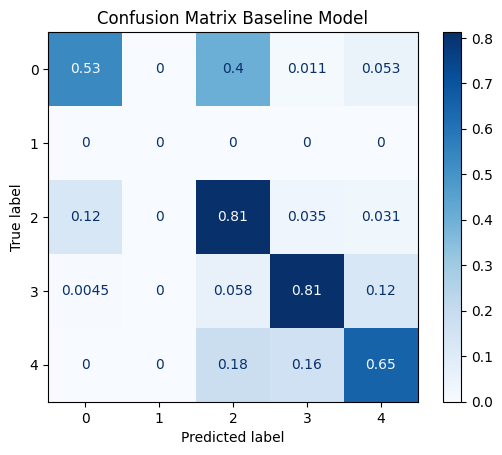

In [53]:
from sklearn.ensemble import HistGradientBoostingClassifier
clf = HistGradientBoostingClassifier(max_depth=5, random_state=0, class_weight='balanced').fit(Xb_train, yb_train)

# predict resistance class
y_pred = clf.predict(Xb_test)

print(classification_report(yb_test, y_pred))

# Display the accuracy
accuracy = np.mean(yb_test == y_pred)
print(f'Accuracy: {accuracy:.2f}')

# Plot the confusion matrix
labels = [0, 1, 2, 3, 4]
cm = confusion_matrix(yb_test, y_pred, normalize = 'true', labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix = cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix Baseline Model")
plt.show()

### 4) Test without drug feature

              precision    recall  f1-score   support

         0.0       0.04      0.61      0.08        94
         2.0       0.99      0.61      0.76      6601
         3.0       0.29      0.79      0.43       224
         4.0       0.03      0.65      0.06        49

    accuracy                           0.62      6968
   macro avg       0.34      0.66      0.33      6968
weighted avg       0.95      0.62      0.73      6968

Accuracy: 0.62


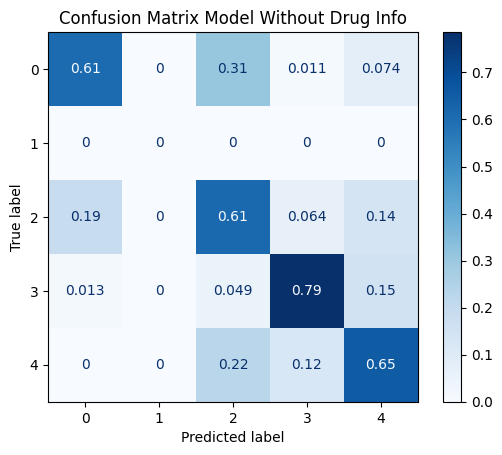

In [57]:
data_without_drug_info = one_hot_df.copy()
drug_columns = ['drug_Amikacin',
       'drug_Bedaquiline', 'drug_Capreomycin', 'drug_Clofazimine',
       'drug_Delamanid', 'drug_Ethambutol', 'drug_Ethionamide',
       'drug_Isoniazid', 'drug_Kanamycin', 'drug_Levofloxacin',
       'drug_Linezolid', 'drug_Moxifloxacin', 'drug_Pyrazinamide',
       'drug_Rifampicin', 'drug_Streptomycin']
data_without_drug_info = data_without_drug_info.drop(columns=drug_columns)

x_base = data_without_drug_info.drop(columns=["grade_ordinal", "gene", "mutation"])
y_base = data_without_drug_info["grade_ordinal"]

x_base = x_base.fillna(0) # sometimes the inserts or deletes are not a number

# split training and test data
Xb_train, Xb_test, yb_train, yb_test = train_test_split(x_base, y_base, test_size=0.2, random_state=42, stratify=y_base)

clf = HistGradientBoostingClassifier(max_depth=5, random_state=0, class_weight='balanced').fit(Xb_train, yb_train)

# predict resistance class
y_pred = clf.predict(Xb_test)

print(classification_report(yb_test, y_pred))

# Display the accuracy
accuracy = np.mean(yb_test == y_pred)
print(f'Accuracy: {accuracy:.2f}')

# Plot the confusion matrix
labels = [0, 1, 2, 3, 4]
cm = confusion_matrix(yb_test, y_pred, normalize = 'true', labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix = cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix Model Without Drug Info")
plt.show()